# Notebook 73 - Exact MATLAB Adaptive Threshold and Hough Peak Parity

Notebook 72 showed two distinct blockers:

1. Python's Hough accumulator matched MATLAB on the exact same mask, but `houghpeaks`/peak ordering did not.
2. Python's aponeurosis adaptive threshold was not MATLAB-like.

This notebook validates the corrected Python ports against the MATLAB debug export for `UltraTimTrack_test.mp4`.

Important dtype note: UltraTimTrack's GUI keeps video frames as `uint8`, but the notebook-72 debug export appears to have sent `double(data)` in the 0-255 range into `imbinarize`. MATLAB `imbinarize` handles those two cases differently. This notebook therefore reports both:

- `source_uint8_exact`: source-code behavior for a `uint8` frame.
- `debug_double255_emulation`: behavior matching the existing debug export's apparent input class/range.

In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.matlab_aponeurosis import adaptive_threshold_matlab_style
from ultrasound_tracker.matlab_timtrack import (
    filter_usimage_hough_matlab_like,
    get_fascicle_mask_matlab_like,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200})

In [2]:
VIDEO_PATH = ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
UTT_EXPORT = Path("/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat")
MATLAB_EXPORT = ROOT / "results" / "notebook72_timtrack_low_level_matlab_export" / "matlab_timtrack_low_level_UltraTimTrack_test.mat"
OUT_DIR = ROOT / "results" / "notebook73_exact_threshold_houghpeaks_parity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Video:", VIDEO_PATH, VIDEO_PATH.exists())
print("UTT export:", UTT_EXPORT, UTT_EXPORT.exists())
print("MATLAB debug export:", MATLAB_EXPORT, MATLAB_EXPORT.exists())
print("Output dir:", OUT_DIR)

Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 True
UTT export: /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat True
MATLAB debug export: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook72_timtrack_low_level_matlab_export/matlab_timtrack_low_level_UltraTimTrack_test.mat True
Output dir: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook73_exact_threshold_houghpeaks_parity


In [3]:
def _decode_attr_bytes(value):
    if isinstance(value, bytes):
        return value.decode()
    if hasattr(value, "item"):
        item = value.item()
        if isinstance(item, bytes):
            return item.decode()
    return value


def _matlab_class(obj):
    return _decode_attr_bytes(obj.attrs.get("MATLAB_class", b"")) if hasattr(obj, "attrs") else ""


def _matlab_fields(group):
    fields = []
    for item in group.attrs.get("MATLAB_fields", []):
        if isinstance(item, np.ndarray):
            fields.append(b"".join(item.tolist()).decode())
        elif isinstance(item, bytes):
            fields.append(item.decode())
        else:
            fields.append(str(item))
    return fields


def _read_h5_dataset(f, ds):
    arr = np.asarray(ds)
    cls = _matlab_class(ds)
    if arr.dtype == object:
        return [_read_h5_obj(f, f[ref]) for ref in arr.reshape(-1)]
    if arr.ndim >= 2:
        arr = arr.T
    if cls == "char":
        return "".join(chr(int(x)) for x in np.asarray(arr).reshape(-1) if int(x) != 0)
    arr = np.squeeze(arr)
    if cls == "logical":
        arr = arr.astype(bool)
    return arr.item() if arr.shape == () else arr


def _read_h5_struct(f, group):
    values = {field: _read_h5_obj(f, group[field]) for field in _matlab_fields(group) if field in group}
    list_lengths = [len(v) for v in values.values() if isinstance(v, list)]
    if list_lengths and len(set(list_lengths)) == 1:
        return [
            {field: (value[i] if isinstance(value, list) else value) for field, value in values.items()}
            for i in range(list_lengths[0])
        ]
    return values


def _read_h5_obj(f, obj):
    if isinstance(obj, h5py.Dataset):
        return _read_h5_dataset(f, obj)
    if isinstance(obj, h5py.Group):
        if _matlab_class(obj) == "struct":
            return _read_h5_struct(f, obj)
        return {key: _read_h5_obj(f, obj[key]) for key in obj.keys()}
    raise TypeError(type(obj))


with h5py.File(MATLAB_EXPORT, "r") as f:
    mat = {key: _read_h5_obj(f, f[key]) for key in f.keys() if key != "#refs#"}

entries = mat["M"]
frames0 = np.asarray(mat["frames0"], dtype=int).reshape(-1)
frames1 = np.asarray(mat["frames1"], dtype=int).reshape(-1)

utt = loadmat(UTT_EXPORT, simplify_cells=True)["UTT_numeric_export"]
parms = utt["parms"]
fas_parms = parms["fas"]
apo_parms = parms["apo"]

print("frames0:", frames0.tolist())
print("apo.th:", apo_parms["th"], "fas.th:", fas_parms["th"])
print("first entry keys:", sorted(entries[0].keys()))

frames0: [0, 1, 2, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2665]
apo.th: 0.5 fas.th: 0.5
first entry keys: ['Emask', 'Emask_radius', 'alpha', 'alphas', 'apo_deep', 'apo_super', 'apo_thres', 'deep_debug', 'deep_vec', 'dohough_x', 'dohough_y', 'fas_filt', 'fas_thres', 'fas_thres_raw', 'fascicle_masked', 'frame0', 'frame1', 'h_by_angle', 'super_debug', 'super_vec', 'weights']


In [4]:
def read_red_frame(video_path: Path, frame0: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame0))
    ok, bgr = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame0={frame0}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb[:, :, 0]


def as_bool(x):
    return np.asarray(x).astype(bool)


def peak_vector(values, n=10):
    arr = np.asarray(values, dtype=float).reshape(-1)
    out = np.full(n, np.nan, dtype=float)
    out[: min(n, arr.size)] = arr[: min(n, arr.size)]
    return out


def binary_metrics(stage, frame0, matlab_mask, python_mask):
    m = as_bool(matlab_mask)
    p = as_bool(python_mask)
    inter = np.logical_and(m, p).sum()
    union = np.logical_or(m, p).sum()
    denom = m.sum() + p.sum()
    diff = np.logical_xor(m, p).sum()
    return {
        "stage": stage,
        "frame0": int(frame0),
        "kind": "binary",
        "matlab_density": float(m.mean()),
        "python_density": float(p.mean()),
        "density_diff_py_minus_mat": float(p.mean() - m.mean()),
        "diff_fraction": float(diff / m.size),
        "different_pixels": int(diff),
        "dice": float(2 * inter / denom) if denom else 1.0,
        "jaccard": float(inter / union) if union else 1.0,
    }


def numeric_metrics(stage, frame0, matlab_value, python_value, unit=""):
    m = np.asarray(matlab_value, dtype=float).reshape(-1)
    p = np.asarray(python_value, dtype=float).reshape(-1)
    n = min(m.size, p.size)
    m = m[:n]
    p = p[:n]
    ok = np.isfinite(m) & np.isfinite(p)
    d = p[ok] - m[ok]
    return {
        "stage": stage,
        "frame0": int(frame0),
        "kind": "numeric",
        "unit": unit,
        "n": int(d.size),
        "bias_py_minus_mat": float(np.mean(d)) if d.size else np.nan,
        "mae": float(np.mean(np.abs(d))) if d.size else np.nan,
        "rmse": float(np.sqrt(np.mean(d**2))) if d.size else np.nan,
        "max_abs": float(np.max(np.abs(d))) if d.size else np.nan,
    }


def hough_params_from_parms(radius):
    return DoHoughParams(
        houghangles=str(fas_parms["houghangles"]),
        angle_range=tuple(np.asarray(fas_parms["range"], dtype=float).reshape(-1)),
        thetares=float(fas_parms["thetares"]),
        rhores=float(fas_parms["rhores"]),
        emask_radius=tuple(np.asarray(radius, dtype=float).reshape(-1)[:2]),
        npeaks=int(fas_parms["npeaks"]),
        replace_diagonal_bias=True,
    )

sample = read_red_frame(VIDEO_PATH, int(frames0[0]))
print("sample dtype/shape/min/max", sample.dtype, sample.shape, int(sample.min()), int(sample.max()))

sample dtype/shape/min/max uint8 (562, 706) 0 255


## 1. Adaptive Threshold Parity

MATLAB `adaptthresh` maps sensitivity to a local-mean scale factor. For bright foreground, `Sensitivity=0.5` maps to scale factor `1.1`, not `0.5`. `imbinarize` then compares integer images in their native class range and floating-point images directly.

The existing debug export looks like it used a floating-point image in the 0-255 range for the aponeurosis threshold. That is tested explicitly as `apo_debug_double255_exact`.

In [5]:
threshold_rows = []
threshold_by_frame = {}
for entry, frame0 in zip(entries, frames0):
    image_uint8 = read_red_frame(VIDEO_PATH, int(frame0))
    image_double255 = image_uint8.astype(float)

    apo_uint8 = adaptive_threshold_matlab_style(image_uint8, sensitivity=float(apo_parms["th"]))
    apo_double255 = adaptive_threshold_matlab_style(image_double255, sensitivity=float(apo_parms["th"]))

    filtered = filter_usimage_hough_matlab_like(image_double255, parms, subtraction_mode="matlab_literal")
    fas_float = adaptive_threshold_matlab_style(filtered["fas_filt"], sensitivity=float(fas_parms["th"]))

    threshold_by_frame[int(frame0)] = {
        "apo_source_uint8_exact": apo_uint8,
        "apo_debug_double255_exact": apo_double255,
        "fas_float_exact": fas_float,
        "filtered_debug_double255": filtered,
    }
    threshold_rows.extend([
        binary_metrics("apo_source_uint8_exact", frame0, entry["apo_thres"], apo_uint8),
        binary_metrics("apo_debug_double255_exact", frame0, entry["apo_thres"], apo_double255),
        binary_metrics("fas_float_exact", frame0, entry["fas_thres_raw"], fas_float),
    ])

threshold_metrics = pd.DataFrame(threshold_rows)
threshold_metrics.to_csv(OUT_DIR / "threshold_metrics_by_frame.csv", index=False)
threshold_summary = (
    threshold_metrics.groupby("stage")
    .agg(
        frames=("frame0", "nunique"),
        mean_dice=("dice", "mean"),
        worst_dice=("dice", "min"),
        mean_diff_fraction=("diff_fraction", "mean"),
        worst_diff_fraction=("diff_fraction", "max"),
        matlab_density=("matlab_density", "mean"),
        python_density=("python_density", "mean"),
    )
    .reset_index()
    .sort_values("mean_diff_fraction")
)
threshold_summary.to_csv(OUT_DIR / "threshold_summary.csv", index=False)
display(threshold_summary)

,stage,frames,mean_dice,worst_dice,mean_diff_fraction,worst_diff_fraction,matlab_density,python_density
2,fas_float_exact,15,0.994576,0.991773,0.002191,0.003067,0.207650,0.206446
0,apo_debug_double255_exact,15,0.964996,0.948953,0.059550,0.082526,0.891948,0.832397
1,apo_source_uint8_exact,15,0.491259,0.484102,0.601554,0.635587,0.891948,0.290394


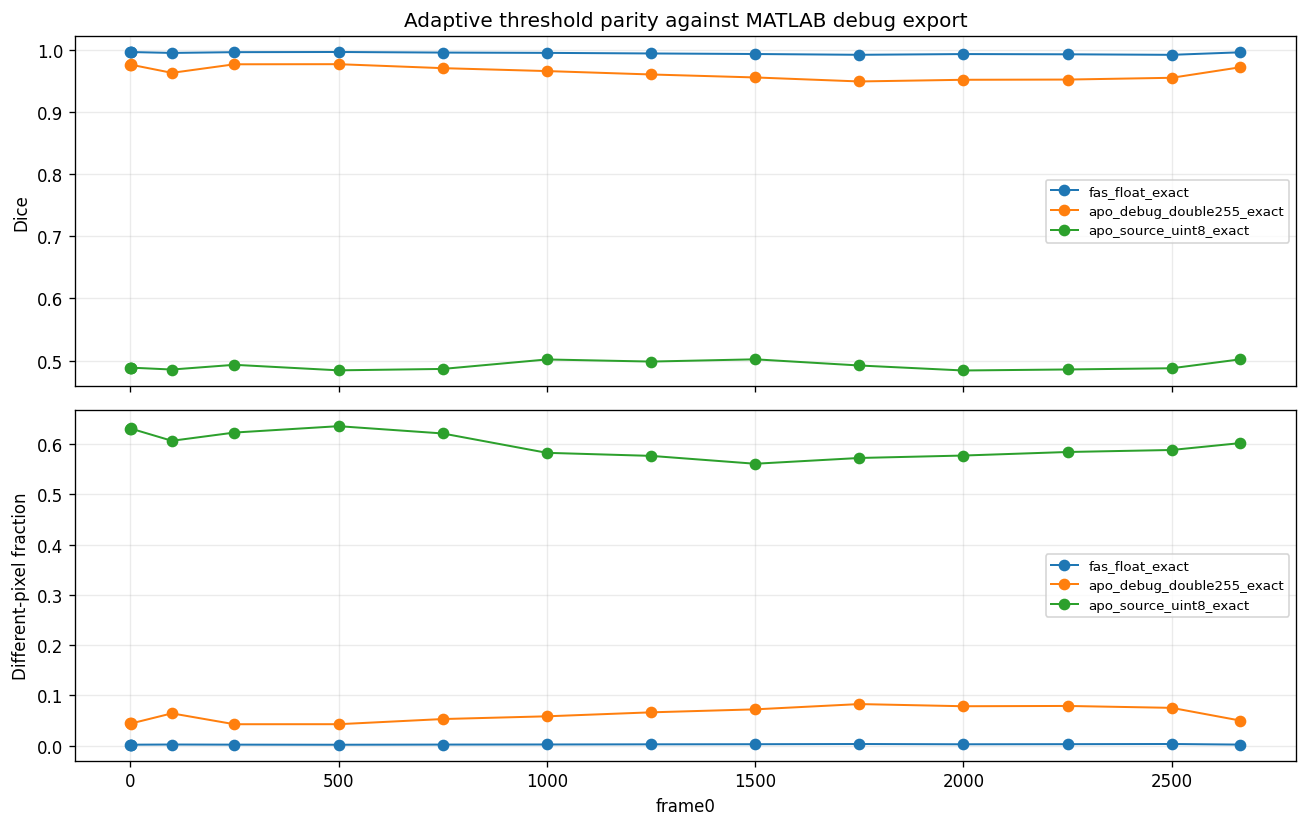

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for stage in threshold_summary["stage"]:
    g = threshold_metrics[threshold_metrics["stage"] == stage].sort_values("frame0")
    axes[0].plot(g["frame0"], g["dice"], marker="o", linewidth=1.2, label=stage)
    axes[1].plot(g["frame0"], g["diff_fraction"], marker="o", linewidth=1.2, label=stage)
axes[0].set_ylabel("Dice")
axes[0].set_title("Adaptive threshold parity against MATLAB debug export")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)
axes[1].set_ylabel("Different-pixel fraction")
axes[1].set_xlabel("frame0")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "threshold_parity_by_frame.png", bbox_inches="tight")
plt.show()

## 2. Hough Peak and Bin-Pixel Parity

This section feeds Python `dohough` the exact MATLAB-exported `fascicle_masked` image. After the `houghpeaks` patch, this should be exact: same alpha, same peak angles, same weights, same accumulator profile, and same peak line endpoints.

In [7]:
hough_rows = []
peak_rows = []
for entry in entries:
    frame0 = int(entry["frame0"])
    result = dohough(as_bool(entry["fascicle_masked"]), hough_params_from_parms(entry["Emask_radius"]))
    hough_rows.extend([
        numeric_metrics("same_mask_alpha", frame0, entry["alpha"], result["alpha"], "deg"),
        numeric_metrics("same_mask_alphas", frame0, peak_vector(entry["alphas"]), peak_vector(result["alphas"]), "deg"),
        numeric_metrics("same_mask_weights", frame0, peak_vector(entry["weights"]), peak_vector(result["weights"]), "votes"),
        numeric_metrics("same_mask_h_by_angle", frame0, entry["h_by_angle"], result["h_by_angle"], "votes"),
        numeric_metrics("same_mask_X", frame0, entry["dohough_x"], result["X"], "px"),
        numeric_metrics("same_mask_Y", frame0, entry["dohough_y"], result["Y"], "px"),
    ])
    for rank in range(10):
        peak_rows.append({
            "frame0": frame0,
            "rank": rank + 1,
            "matlab_alpha": peak_vector(entry["alphas"])[rank],
            "python_alpha": peak_vector(result["alphas"])[rank],
            "matlab_weight": peak_vector(entry["weights"])[rank],
            "python_weight": peak_vector(result["weights"])[rank],
            "matlab_x1": np.asarray(entry["dohough_x"], dtype=float).reshape(10, 2)[rank, 0],
            "python_x1": np.asarray(result["X"], dtype=float).reshape(10, 2)[rank, 0],
            "matlab_y1": np.asarray(entry["dohough_y"], dtype=float).reshape(10, 2)[rank, 0],
            "python_y1": np.asarray(result["Y"], dtype=float).reshape(10, 2)[rank, 0],
        })

hough_metrics = pd.DataFrame(hough_rows)
hough_metrics.to_csv(OUT_DIR / "hough_same_mask_metrics_by_frame.csv", index=False)
peak_table = pd.DataFrame(peak_rows)
peak_table.to_csv(OUT_DIR / "hough_same_mask_peak_table.csv", index=False)

hough_summary = (
    hough_metrics.groupby(["stage", "unit"])
    .agg(
        frames=("frame0", "nunique"),
        mean_mae=("mae", "mean"),
        worst_mae=("mae", "max"),
        mean_max_abs=("max_abs", "mean"),
        worst_max_abs=("max_abs", "max"),
    )
    .reset_index()
    .sort_values("worst_mae", ascending=False)
)
hough_summary.to_csv(OUT_DIR / "hough_same_mask_summary.csv", index=False)
display(hough_summary)
display(peak_table.head(20))

,stage,unit,frames,mean_mae,worst_mae,mean_max_abs,worst_max_abs
0,same_mask_X,px,15,0.0,0.0,0.0,0.0
1,same_mask_Y,px,15,0.0,0.0,0.0,0.0
2,same_mask_alpha,deg,15,0.0,0.0,0.0,0.0
3,same_mask_alphas,deg,15,0.0,0.0,0.0,0.0
4,same_mask_h_by_angle,votes,15,0.0,0.0,0.0,0.0
5,same_mask_weights,votes,15,0.0,0.0,0.0,0.0


,frame0,rank,matlab_alpha,python_alpha,matlab_weight,python_weight,matlab_x1,python_x1,matlab_y1,python_y1
0,0,1,19.0,19.0,371.0,371.0,130.0,130.0,250.0,250.0
1,0,2,21.0,21.0,346.0,346.0,227.0,227.0,275.0,275.0
2,0,3,25.5,25.5,291.0,291.0,320.0,320.0,295.0,295.0
3,0,4,19.0,19.0,290.0,290.0,21.0,21.0,208.0,208.0
4,0,5,21.0,21.0,280.0,280.0,50.0,50.0,239.0,239.0
5,0,6,23.0,23.0,275.0,275.0,313.0,313.0,295.0,295.0
6,0,7,19.5,19.5,269.0,269.0,212.0,212.0,272.0,272.0
7,0,8,10.5,10.5,269.0,269.0,21.0,21.0,204.0,204.0
8,0,9,20.5,20.5,268.0,268.0,318.0,318.0,288.0,288.0
9,0,10,8.5,8.5,268.0,268.0,54.0,54.0,191.0,191.0


## 3. Full Low-Level Pipeline Modes

This final check compares two full low-level Python modes against the current MATLAB debug export:

- `source_uint8_exact`: use true MATLAB `uint8` threshold behavior.
- `debug_double255_emulation`: emulate the apparent dtype/range used by the debug export.

The second mode is expected to match the debug masks better. The first mode is the source-faithful behavior if the GUI passes `uint8` frames to `auto_ultrasound`.

In [8]:
def run_low_level(image_for_filter):
    filtered = filter_usimage_hough_matlab_like(image_for_filter, parms, subtraction_mode="matlab_literal")
    emask, radius, mean_depths = get_fascicle_mask_matlab_like(
        filtered["fas_thres"], filtered["super_vec_1b"], filtered["deep_vec_1b"]
    )
    fascicle_masked = as_bool(filtered["fas_thres"]) & as_bool(emask)
    hough = dohough(fascicle_masked, hough_params_from_parms(radius))
    return {**filtered, "Emask": emask, "Emask_radius": np.asarray(radius), "fascicle_masked": fascicle_masked, "hough": hough, "alpha": hough["alpha"]}

full_rows = []
alpha_rows = []
for entry, frame0 in zip(entries, frames0):
    image_uint8 = read_red_frame(VIDEO_PATH, int(frame0))
    modes = {
        "source_uint8_exact": run_low_level(image_uint8),
        "debug_double255_emulation": run_low_level(image_uint8.astype(float)),
    }
    for mode, result in modes.items():
        full_rows.extend([
            binary_metrics(f"{mode}:apo_thres", frame0, entry["apo_thres"], result["apo_thres"]),
            binary_metrics(f"{mode}:apo_super", frame0, entry["apo_super"], result["apo_super"]),
            binary_metrics(f"{mode}:apo_deep", frame0, entry["apo_deep"], result["apo_deep"]),
            binary_metrics(f"{mode}:fas_thres_raw", frame0, entry["fas_thres_raw"], result["fas_thres_raw"]),
            binary_metrics(f"{mode}:fas_thres", frame0, entry["fas_thres"], result["fas_thres"]),
            binary_metrics(f"{mode}:Emask", frame0, entry["Emask"], result["Emask"]),
            binary_metrics(f"{mode}:fascicle_masked", frame0, entry["fascicle_masked"], result["fascicle_masked"]),
            numeric_metrics(f"{mode}:super_vec", frame0, entry["super_vec"], result["super_vec_1b"], "px"),
            numeric_metrics(f"{mode}:deep_vec", frame0, entry["deep_vec"], result["deep_vec_1b"], "px"),
            numeric_metrics(f"{mode}:alpha", frame0, entry["alpha"], result["alpha"], "deg"),
        ])
        alpha_rows.append({"frame0": int(frame0), "mode": mode, "matlab_export_alpha": float(entry["alpha"]), "python_alpha": float(result["alpha"]), "diff": float(result["alpha"] - entry["alpha"])})

full_metrics = pd.DataFrame(full_rows)
alpha_modes = pd.DataFrame(alpha_rows)
full_metrics.to_csv(OUT_DIR / "full_low_level_mode_metrics_by_frame.csv", index=False)
alpha_modes.to_csv(OUT_DIR / "full_low_level_alpha_modes.csv", index=False)

binary_summary = (
    full_metrics[full_metrics["kind"] == "binary"]
    .assign(mode=lambda d: d["stage"].str.split(":").str[0], substage=lambda d: d["stage"].str.split(":").str[1])
    .groupby(["mode", "substage"])
    .agg(mean_dice=("dice", "mean"), worst_dice=("dice", "min"), mean_diff_fraction=("diff_fraction", "mean"))
    .reset_index()
)
numeric_summary = (
    full_metrics[full_metrics["kind"] == "numeric"]
    .assign(mode=lambda d: d["stage"].str.split(":").str[0], substage=lambda d: d["stage"].str.split(":").str[1])
    .groupby(["mode", "substage", "unit"])
    .agg(mean_mae=("mae", "mean"), worst_mae=("mae", "max"))
    .reset_index()
)
binary_summary.to_csv(OUT_DIR / "full_low_level_binary_summary.csv", index=False)
numeric_summary.to_csv(OUT_DIR / "full_low_level_numeric_summary.csv", index=False)

display(binary_summary.sort_values(["substage", "mode"]))
display(numeric_summary.sort_values(["substage", "mode"]))

,mode,substage,mean_dice,worst_dice,mean_diff_fraction
0,debug_double255_emulation,Emask,0.976099,0.955314,0.016138
7,source_uint8_exact,Emask,0.935019,0.906159,0.045657
1,debug_double255_emulation,apo_deep,0.975461,0.969738,0.005803
8,source_uint8_exact,apo_deep,0.512226,0.467813,0.079520
2,debug_double255_emulation,apo_super,0.965420,0.961453,0.007379
9,source_uint8_exact,apo_super,0.488470,0.480190,0.074694
3,debug_double255_emulation,apo_thres,0.964996,0.948953,0.059550
10,source_uint8_exact,apo_thres,0.491259,0.484102,0.601554
4,debug_double255_emulation,fas_thres,0.987978,0.984087,0.004891
11,source_uint8_exact,fas_thres,0.987978,0.984087,0.004891


,mode,substage,unit,mean_mae,worst_mae
0,debug_double255_emulation,alpha,deg,0.400000,1.5
3,source_uint8_exact,alpha,deg,2.000000,11.5
1,debug_double255_emulation,deep_vec,px,4.113333,16.9
4,source_uint8_exact,deep_vec,px,12.880000,25.9
2,debug_double255_emulation,super_vec,px,8.213333,18.1
5,source_uint8_exact,super_vec,px,23.200000,26.4


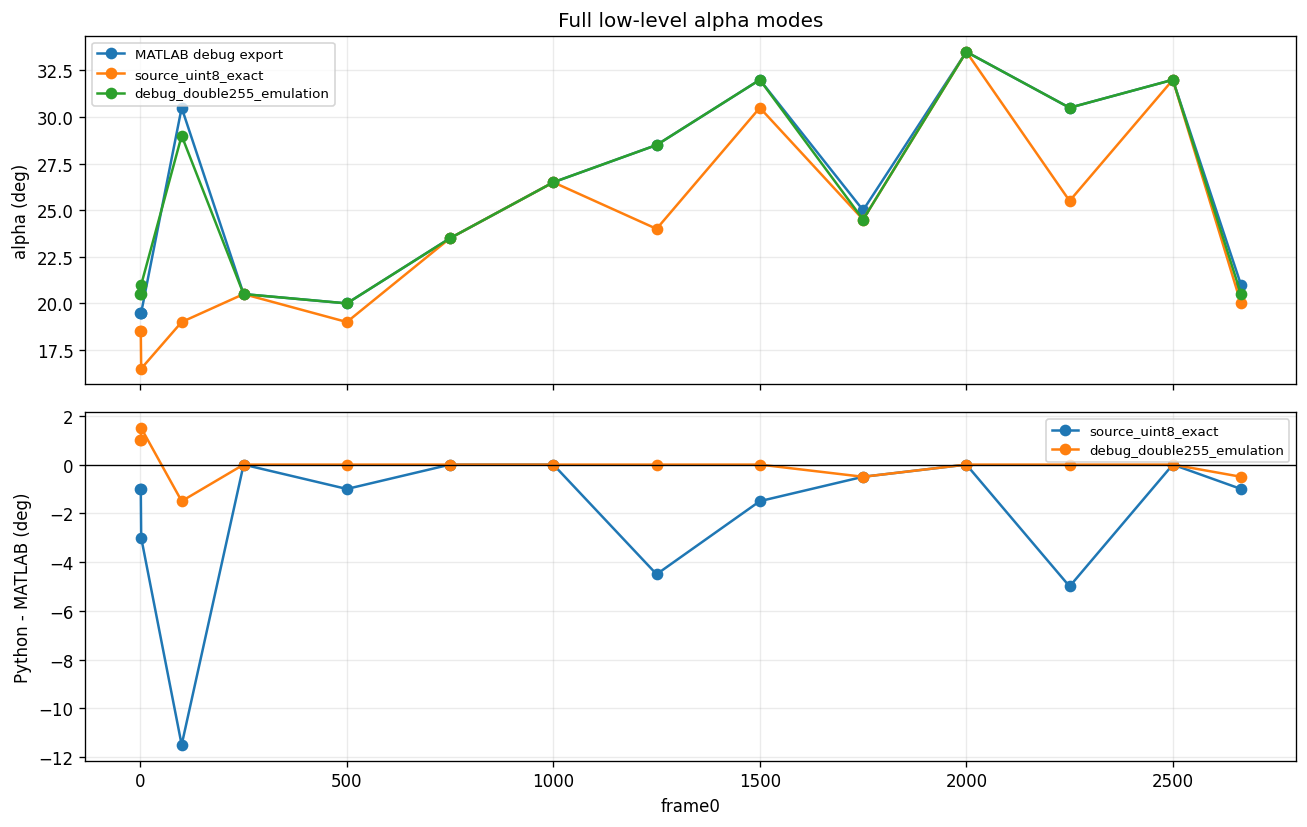

In [9]:
wide = alpha_modes.pivot(index="frame0", columns="mode", values="python_alpha").reset_index()
wide["matlab_export_alpha"] = alpha_modes.groupby("frame0")["matlab_export_alpha"].first().values
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(wide["frame0"], wide["matlab_export_alpha"], marker="o", label="MATLAB debug export")
for mode in ["source_uint8_exact", "debug_double255_emulation"]:
    axes[0].plot(wide["frame0"], wide[mode], marker="o", label=mode)
    axes[1].plot(wide["frame0"], wide[mode] - wide["matlab_export_alpha"], marker="o", label=mode)
axes[0].set_ylabel("alpha (deg)")
axes[0].set_title("Full low-level alpha modes")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Python - MATLAB (deg)")
axes[1].set_xlabel("frame0")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "full_low_level_alpha_modes.png", bbox_inches="tight")
plt.show()

In [10]:
summary_lines = []
summary_lines.append("# Notebook 73 summary")
summary_lines.append("")
summary_lines.append("## Threshold")
for _, row in threshold_summary.iterrows():
    summary_lines.append(
        f"- {row['stage']}: mean Dice {row['mean_dice']:.6f}, worst Dice {row['worst_dice']:.6f}, mean diff fraction {row['mean_diff_fraction']:.6f}."
    )
summary_lines.append("")
summary_lines.append("## Same-mask Hough")
for _, row in hough_summary.iterrows():
    summary_lines.append(
        f"- {row['stage']}: mean MAE {row['mean_mae']:.6g} {row['unit']}, worst MAE {row['worst_mae']:.6g}."
    )
summary_lines.append("")
summary_lines.append("## Full Low-Level Modes")
for _, row in numeric_summary[numeric_summary["substage"].eq("alpha")].iterrows():
    summary_lines.append(
        f"- {row['mode']} alpha: mean MAE {row['mean_mae']:.6g} deg, worst MAE {row['worst_mae']:.6g} deg."
    )
summary_text = "\n".join(summary_lines)
(OUT_DIR / "notebook73_summary.md").write_text(summary_text)
print(summary_text)

print("\nSaved outputs:")
for path in sorted(OUT_DIR.glob("*")):
    print("-", path)

# Notebook 73 summary

## Threshold
- fas_float_exact: mean Dice 0.994576, worst Dice 0.991773, mean diff fraction 0.002191.
- apo_debug_double255_exact: mean Dice 0.964996, worst Dice 0.948953, mean diff fraction 0.059550.
- apo_source_uint8_exact: mean Dice 0.491259, worst Dice 0.484102, mean diff fraction 0.601554.

## Same-mask Hough
- same_mask_X: mean MAE 0 px, worst MAE 0.
- same_mask_Y: mean MAE 0 px, worst MAE 0.
- same_mask_alpha: mean MAE 0 deg, worst MAE 0.
- same_mask_alphas: mean MAE 0 deg, worst MAE 0.
- same_mask_h_by_angle: mean MAE 0 votes, worst MAE 0.
- same_mask_weights: mean MAE 0 votes, worst MAE 0.

## Full Low-Level Modes
- debug_double255_emulation alpha: mean MAE 0.4 deg, worst MAE 1.5 deg.
- source_uint8_exact alpha: mean MAE 2 deg, worst MAE 11.5 deg.

Saved outputs:
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook73_exact_threshold_houghpeaks_parity/full_low_level_alpha_modes.csv
- /Users/grosbedou/PycharmProjects/NDORMS/results/notebook73_exact_